In [336]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, softmax
from sklearn.preprocessing import RobustScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [337]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
time_col = 'ENGINE_RUN_TINE ()'

files = [file for file in os.listdir(path) if file.endswith('.csv')]

df_list = []
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(f'{path}/{file}', index_col=False)
        df['drive_id'] = file
        df_list.append(df)


print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


# %%
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
    """
    Compute std of each std-computable column (numeric only)
    """
    if exclude_cols is None:
        exclude_cols = []
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
    std_df = df[cols_to_check].std()
    zero_variance_cols = std_df[std_df == 0].index.tolist()
  
    print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
    if len(zero_variance_cols) > 0:
        df = df.drop(columns=zero_variance_cols)
  
    return df


# %%
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, time_col: str, id_cols: list[str] = None) -> pd.DataFrame:
    """
    Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
    This preserves the overall statistics while removing duplicate entries.
    
    Note: The time column itself is not averaged (it becomes the group key).
    Only numeric columns are averaged when multiple rows share the same timestamp.
    """
    if id_cols is None:
        id_cols = []
    
    existing_id_cols = [col for col in id_cols if col in df.columns]
    
    group_cols = [time_col] + existing_id_cols
    
    agg_dict = {}
    for col in df.columns:
        if col not in group_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                agg_dict[col] = 'mean'
            else:
                agg_dict[col] = 'first'
  
    df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
    return df_clean


# %%
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


# %%
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)


# %%
# Combine all dataframes
data = pd.concat(df_list, ignore_index=True)


# Clean up
print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")


# remove some useless columns
data = data.drop(columns=['WARM_UPS_SINCE_CODES_CLEARED ()', 'TIME_SINCE_TROUBLE_CODES_CLEARED ()'])


data = mean_fill_missing_timestamps_and_remove_duplicates(data, time_col=time_col, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col=time_col,
    source_file_col='drive_id',
    downsample_factor=1
)
data.drop(columns=["drive_id"], inplace=True)


129 files loaded out of 129
Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']


In [338]:
train_ratio = 0.7
val_ratio = 0.15

train_size = int(len(data) * train_ratio)
val_size = int(len(data) * val_ratio)

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

scaler = RobustScaler()
train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

train_data_scaled = np.clip(train_data_scaled, -10, 10)
val_data_scaled = np.clip(val_data_scaled, -10, 10)  
test_data_scaled = np.clip(test_data_scaled, -10, 10)

print(f"Train: {train_data_scaled.shape}")
print(f"Val: {val_data_scaled.shape}")
print(f"Test: {test_data_scaled.shape}")

def create_sliding_windows(data, window_size=5):
    """
    Create sliding windows for time series
    X: [num_samples, num_features, window_size] - input windows
    y: [num_samples, num_features] - target values (next timestep)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size].T)  # [num_features, window_size]
        y.append(data[i+window_size])      # [num_features]
    return np.array(X), np.array(y)

window_size = 5
X_train, y_train = create_sliding_windows(train_data_scaled, window_size)
X_val, y_val = create_sliding_windows(val_data_scaled, window_size)
X_test, y_test = create_sliding_windows(test_data_scaled, window_size)

print(f"X_train shape: {X_train.shape}")  # [samples, num_features, window_size]
print(f"y_train shape: {y_train.shape}")  # [samples, num_features]

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Train: (57684, 22)
Val: (12361, 22)
Test: (12362, 22)
X_train shape: (57679, 22, 5)
y_train shape: (57679, 22)
Number of training batches: 902
Number of validation batches: 194
Number of test batches: 194


In [339]:
class GraphAttentionLayer(MessagePassing):
    """
    Numerically stable Graph Attention Layer
    """
    def __init__(self, in_dim, out_dim, embed_dim):
        super().__init__(aggr='add')
        
        # Feature transformation
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        
        # Attention mechanism
        self.att = nn.Linear(2 * (embed_dim + out_dim), 1, bias=False)
        
        self.embed_dim = embed_dim
        self.out_dim = out_dim
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        # ✅ CRITICAL: Initialize weights properly
        nn.init.xavier_normal_(self.W.weight, gain=0.1)
        nn.init.xavier_normal_(self.att.weight, gain=0.1)
    
    def forward(self, x, edge_index, embeddings):
        """
        x: [num_nodes, in_dim]
        edge_index: [2, num_edges]
        embeddings: [num_nodes, embed_dim]
        """
        # ✅ Check for NaN in inputs
        if torch.isnan(x).any():
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)
        
        if torch.isnan(embeddings).any():
            embeddings = torch.nan_to_num(embeddings, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # Transform features
        x_transformed = self.W(x)
        
        # ✅ Check after transformation
        if torch.isnan(x_transformed).any():
            x_transformed = torch.nan_to_num(x_transformed, nan=0.0)
        
        # Concatenate with embeddings
        x_with_embed = torch.cat([embeddings, x_transformed], dim=1)
        
        # Message passing
        out = self.propagate(edge_index, x=x_with_embed, size=None)
        
        return F.relu(out)
    
    def message(self, x_i, x_j, edge_index_i, size_i):
        """
        ✅ FIXED: Added size_i parameter (critical for batched graphs!)
        """
        # Concatenate source and target
        x_cat = torch.cat([x_i, x_j], dim=-1)
        
        # Clamp to prevent extreme values
        x_cat = torch.clamp(x_cat, min=-5.0, max=5.0)  # ✅ Reduced from 10
        
        # Compute attention score
        alpha = self.att(x_cat)
        alpha = self.leaky_relu(alpha)
        
        # ✅ Clamp more aggressively
        alpha = torch.clamp(alpha, min=-5.0, max=5.0)
        
        # ✅ CRITICAL FIX: Pass size_i to softmax for batched graphs
        alpha = softmax(alpha, edge_index_i, num_nodes=size_i)
        
        # ✅ Add epsilon to prevent zero division
        alpha = alpha + 1e-8
        
        # ✅ Check for NaN after softmax
        if torch.isnan(alpha).any() or torch.isinf(alpha).any():
            alpha = torch.nan_to_num(alpha, nan=1e-8, posinf=1.0, neginf=0.0)
        
        # Get features and clamp
        x_j_features = x_j[:, -self.out_dim:]
        x_j_features = torch.clamp(x_j_features, min=-5.0, max=5.0)
        
        # Weighted message
        message = alpha * x_j_features
        
        # ✅ Final NaN check
        if torch.isnan(message).any():
            message = torch.nan_to_num(message, nan=0.0)
        
        return message


In [340]:
class GDN(nn.Module):
    def __init__(self, num_features, window_size, hidden_dim=64, embed_dim=64, topk=15):
        super().__init__()
        
        self.num_features = num_features
        self.window_size = window_size
        self.hidden_dim = hidden_dim
        self.embed_dim = embed_dim
        self.topk = min(topk, num_features - 1)
        
        # ✅ Smaller initialization
        self.embeddings = nn.Parameter(torch.randn(num_features, embed_dim) * 0.01)
        
        self.gat1 = GraphAttentionLayer(window_size, hidden_dim, embed_dim)
        self.gat2 = GraphAttentionLayer(hidden_dim, hidden_dim, embed_dim)
        
        self.fc = nn.Linear(hidden_dim, 1)
        
        # ✅ Initialize fc layer
        nn.init.xavier_normal_(self.fc.weight, gain=0.1)
        nn.init.constant_(self.fc.bias, 0)
        
        self.dropout = nn.Dropout(0.2)
        
        self.register_buffer('edge_index', None)
        self._edge_cache = {}
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Custom weight initialization"""
        if isinstance(module, nn.Linear):
            # Use smaller gain and ensure weights are not too large
            nn.init.xavier_normal_(module.weight, gain=0.1)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Parameter):
            # Ensure embeddings are small
            if module.data.size(0) == self.num_features:
                nn.init.normal_(module.data, mean=0.0, std=0.01)
    
    def learn_graph_structure(self):
        """Learn graph structure from embeddings"""
        # Ensure embeddings are not NaN or Inf
        if torch.isnan(self.embeddings).any() or torch.isinf(self.embeddings).any():
            print("Warning: Embeddings contain NaN/Inf, reinitializing...")
            nn.init.normal_(self.embeddings, mean=0.0, std=0.01)
        
        # Safe normalization: handle zero-norm vectors
        norms = torch.norm(self.embeddings, p=2, dim=1, keepdim=True)
        norms = torch.clamp(norms, min=1e-8)  # Prevent division by zero
        embeddings_norm = self.embeddings / norms
        
        # Check for NaN after normalization
        if torch.isnan(embeddings_norm).any():
            print("Warning: Normalized embeddings contain NaN, using identity")
            embeddings_norm = torch.eye(self.num_features, device=self.embeddings.device) * 0.01
        
        similarity = torch.mm(embeddings_norm, embeddings_norm.t())
        
        # Clamp similarity to valid range
        similarity = torch.clamp(similarity, min=-1.0, max=1.0)
        
        # Check for NaN in similarity
        if torch.isnan(similarity).any():
            print("Warning: Similarity matrix contains NaN, using identity")
            similarity = torch.eye(self.num_features, device=self.embeddings.device)
        
        similarity.fill_diagonal_(-1e9)
        
        _, topk_indices = torch.topk(similarity, self.topk, dim=1)
        
        edge_list = []
        for i in range(self.num_features):
            for j in topk_indices[i]:
                edge_list.append([j.item(), i])
        
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        
        # Validate edge_index
        if edge_index.size(0) != 2 or edge_index.size(1) == 0:
            raise ValueError(f"Invalid edge_index: {edge_index.shape}")
        
        return edge_index
    
    def get_batched_edge_index(self, batch_size, device):
        """Get or create cached batched edge index"""
        cache_key = (batch_size, str(device))
        if cache_key in self._edge_cache:
            return self._edge_cache[cache_key]
        
        offsets = torch.arange(batch_size, device=device) * self.num_features
        offsets = offsets.view(1, batch_size, 1)
        
        edge_index_batched = self.edge_index.unsqueeze(1) + offsets
        edge_index_batched = edge_index_batched.reshape(2, -1)
        
        self._edge_cache[cache_key] = edge_index_batched
        return edge_index_batched
    
    def forward(self, x):
        """
        x: [batch_size, num_features, window_size]
        """
        batch_size = x.size(0)
        device = x.device
        
        if self.edge_index is None:
            self.edge_index = self.learn_graph_structure().to(device)
        
        x_flat = x.reshape(batch_size * self.num_features, self.window_size)
        batch_embeddings = self.embeddings.repeat(batch_size, 1)
        
        edge_index_batch = self.get_batched_edge_index(batch_size, device)
        
        # Graph layers with checks
        h1 = self.gat1(x_flat, edge_index_batch, batch_embeddings)
        h1 = self.dropout(h1)
        
        h2 = self.gat2(h1, edge_index_batch, batch_embeddings)
        
        # Element-wise multiplication with embeddings (only if dimensions match)
        # Use embedding projection if needed
        if batch_embeddings.size(1) >= self.hidden_dim:
            h2 = h2 * batch_embeddings[:, :self.hidden_dim]
        else:
            # If embedding dim is smaller, pad or use a projection
            embed_proj = batch_embeddings[:, :min(self.hidden_dim, batch_embeddings.size(1))]
            if embed_proj.size(1) < self.hidden_dim:
                # Pad with ones if needed
                padding = torch.ones(batch_embeddings.size(0), self.hidden_dim - embed_proj.size(1), 
                                   device=batch_embeddings.device)
                embed_proj = torch.cat([embed_proj, padding], dim=1)
            h2 = h2 * embed_proj
        
        forecast = self.fc(h2).squeeze(-1)
        forecast = forecast.reshape(batch_size, self.num_features)
        
        # Clamp output to prevent extreme values
        forecast = torch.clamp(forecast, min=-10.0, max=10.0)
        
        return forecast


In [341]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


num_features = X_train.shape[1]
model = GDN(
    num_features=num_features,
    window_size=window_size,
    hidden_dim=64,
    embed_dim=64,
    topk=10
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001,
    betas=(0.9, 0.99),
    weight_decay=0.0001
)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)
criterion = nn.MSELoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            
            total_loss += loss.item()
    
    return total_loss / len(val_loader)


Using device: mps
Model parameters: 6,401


In [342]:
#epochs = 50
#best_val_loss = float('inf')
#patience = 10
#patience_counter = 0

#train_losses = []
#val_losses = []

#print("Training GDN with optimized DataLoader...")
#print("="*60)

#for epoch in tqdm(range(epochs), desc='Epochs'):
#    # Train
#    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    
#    # Validate
#    val_loss = validate(model, val_loader, criterion, device)
    
#    # Check for NaN
#    if np.isnan(train_loss) or np.isnan(val_loss):
#        print(f"\nNaN detected at epoch {epoch}!")
#        print(f"Train loss: {train_loss}, Val loss: {val_loss}")
#        break
    
#    train_losses.append(train_loss)
#    val_losses.append(val_loss)
    
#    # Update learning rate based on validation loss
#    scheduler.step(val_loss)  # ✅ Correct: after validation, with val_loss
    
#    # Save best model
#    if val_loss < best_val_loss:
#        best_val_loss = val_loss
#        torch.save(model.state_dict(), 'best_gdn_model.pt')
#        patience_counter = 0
#    else:
#        patience_counter += 1
    
#    if epoch % 5 == 0:
#        tqdm.write(f'Epoch {epoch:03d}: Train Loss={train_loss:.6f}, '
#                    f'Val Loss={val_loss:.6f}, Best={best_val_loss:.6f}')
    
#    # Early stopping
#    if patience_counter >= patience:
#        print(f"\nEarly stopping at epoch {epoch}")
#        break

#print("="*60)
#print(f"Best validation loss: {best_val_loss:.6f}")


In [343]:
# %%
def compute_anomaly_scores(model, data_loader, device):
    """
    Compute anomaly scores using DataLoader
    """
    model.eval()
    all_errors = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            y_pred = model(batch_X)
            errors = torch.abs(y_pred - batch_y).cpu().numpy()
            all_errors.append(errors)
    
    all_errors = np.vstack(all_errors)
    
    # Robust normalization per sensor
    median = np.median(all_errors, axis=0)
    q75 = np.percentile(all_errors, 75, axis=0)
    q25 = np.percentile(all_errors, 25, axis=0)
    iqr = q75 - q25
    iqr[iqr == 0] = 1
    
    normalized_errors = (all_errors - median) / iqr
    anomaly_scores = np.max(normalized_errors, axis=1)
    
    return anomaly_scores, normalized_errors, all_errors


# Compute scores
val_scores, val_sensor_scores, val_errors = compute_anomaly_scores(
    model, val_loader, device
)
test_scores, test_sensor_scores, test_errors = compute_anomaly_scores(
    model, test_loader, device
)


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_28771/3340748014.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(box_data, labels=['Validation', 'Test'], patch_artist=True)


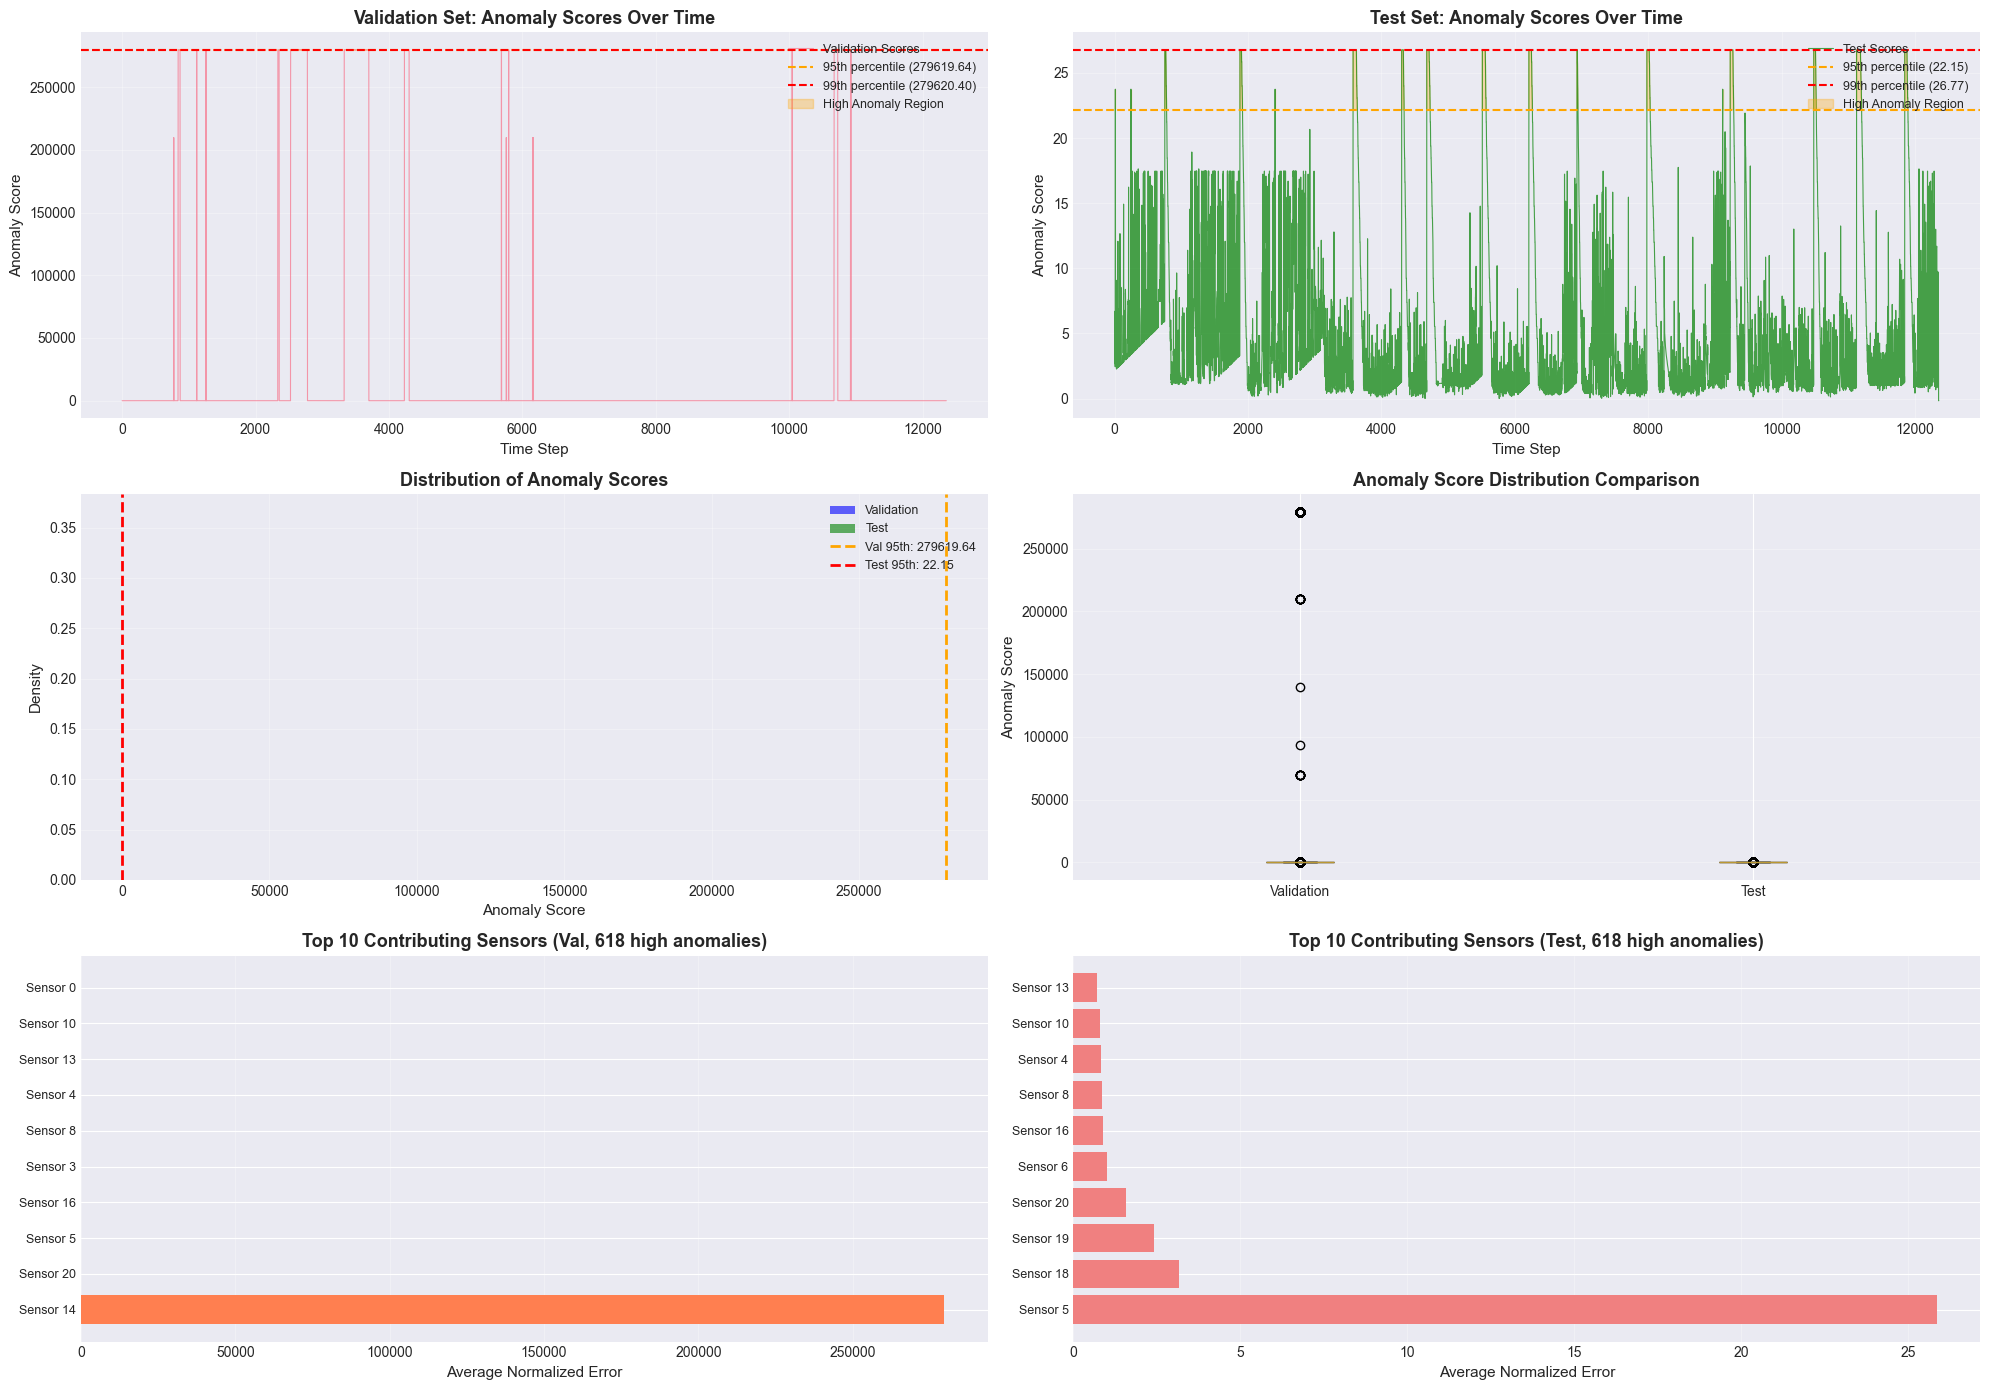

ANOMALY SCORE SUMMARY STATISTICS

Validation Set:
  Mean: 18702.9507
  Median: 1.6788
  Std: 69676.3776
  Min: -0.3759
  Max: 279625.9667
  95th percentile: 279619.6417
  99th percentile: 279620.4000
  High anomalies (>= 95th percentile): 618 (5.00%)

Test Set:
  Mean: 5.3408
  Median: 2.4615
  Std: 6.6061
  Min: -0.1667
  Max: 26.7693
  95th percentile: 22.1539
  99th percentile: 26.7693
  High anomalies (>= 95th percentile): 618 (5.00%)


In [344]:
# Visualize anomaly scores
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots
fig = plt.figure(figsize=(20, 14))

# 1. Time series of anomaly scores (Validation)
ax1 = plt.subplot(3, 2, 1)
ax1.plot(val_scores, alpha=0.7, linewidth=0.8, label='Validation Scores')
# Highlight high anomaly regions
threshold_95 = np.percentile(val_scores, 95)
threshold_99 = np.percentile(val_scores, 99)
ax1.axhline(y=threshold_95, color='orange', linestyle='--', linewidth=1.5, label=f'95th percentile ({threshold_95:.2f})')
ax1.axhline(y=threshold_99, color='red', linestyle='--', linewidth=1.5, label=f'99th percentile ({threshold_99:.2f})')
ax1.fill_between(range(len(val_scores)), val_scores, threshold_95, where=(val_scores >= threshold_95), 
                 alpha=0.3, color='orange', label='High Anomaly Region')
ax1.set_xlabel('Time Step', fontsize=11)
ax1.set_ylabel('Anomaly Score', fontsize=11)
ax1.set_title('Validation Set: Anomaly Scores Over Time', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Time series of anomaly scores (Test)
ax2 = plt.subplot(3, 2, 2)
ax2.plot(test_scores, alpha=0.7, linewidth=0.8, label='Test Scores', color='green')
# Highlight high anomaly regions
threshold_95_test = np.percentile(test_scores, 95)
threshold_99_test = np.percentile(test_scores, 99)
ax2.axhline(y=threshold_95_test, color='orange', linestyle='--', linewidth=1.5, label=f'95th percentile ({threshold_95_test:.2f})')
ax2.axhline(y=threshold_99_test, color='red', linestyle='--', linewidth=1.5, label=f'99th percentile ({threshold_99_test:.2f})')
ax2.fill_between(range(len(test_scores)), test_scores, threshold_95_test, where=(test_scores >= threshold_95_test), 
                 alpha=0.3, color='orange', label='High Anomaly Region')
ax2.set_xlabel('Time Step', fontsize=11)
ax2.set_ylabel('Anomaly Score', fontsize=11)
ax2.set_title('Test Set: Anomaly Scores Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Distribution of anomaly scores
ax3 = plt.subplot(3, 2, 3)
ax3.hist(val_scores, bins=50, alpha=0.6, label='Validation', density=True, color='blue')
ax3.hist(test_scores, bins=50, alpha=0.6, label='Test', density=True, color='green')
ax3.axvline(x=threshold_95, color='orange', linestyle='--', linewidth=2, label=f'Val 95th: {threshold_95:.2f}')
ax3.axvline(x=threshold_95_test, color='red', linestyle='--', linewidth=2, label=f'Test 95th: {threshold_95_test:.2f}')
ax3.set_xlabel('Anomaly Score', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('Distribution of Anomaly Scores', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Box plot comparison
ax4 = plt.subplot(3, 2, 4)
box_data = [val_scores, test_scores]
bp = ax4.boxplot(box_data, labels=['Validation', 'Test'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
ax4.set_ylabel('Anomaly Score', fontsize=11)
ax4.set_title('Anomaly Score Distribution Comparison', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Top contributing sensors for high anomalies (Validation)
ax5 = plt.subplot(3, 2, 5)
high_anomaly_indices = np.where(val_scores >= threshold_95)[0]
if len(high_anomaly_indices) > 0:
    high_anomaly_sensor_scores = val_sensor_scores[high_anomaly_indices]
    sensor_contributions = np.mean(np.abs(high_anomaly_sensor_scores), axis=0)
    top_sensors = np.argsort(sensor_contributions)[-10:][::-1]
    
    y_pos = np.arange(len(top_sensors))
    ax5.barh(y_pos, sensor_contributions[top_sensors], color='coral')
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels([f'Sensor {i}' for i in top_sensors], fontsize=9)
    ax5.set_xlabel('Average Normalized Error', fontsize=11)
    ax5.set_title(f'Top 10 Contributing Sensors (Val, {len(high_anomaly_indices)} high anomalies)', 
                  fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='x')
else:
    ax5.text(0.5, 0.5, 'No high anomalies found', ha='center', va='center', fontsize=12)
    ax5.set_title('Top Contributing Sensors (Validation)', fontsize=13, fontweight='bold')

# 6. Top contributing sensors for high anomalies (Test)
ax6 = plt.subplot(3, 2, 6)
high_anomaly_indices_test = np.where(test_scores >= threshold_95_test)[0]
if len(high_anomaly_indices_test) > 0:
    high_anomaly_sensor_scores_test = test_sensor_scores[high_anomaly_indices_test]
    sensor_contributions_test = np.mean(np.abs(high_anomaly_sensor_scores_test), axis=0)
    top_sensors_test = np.argsort(sensor_contributions_test)[-10:][::-1]
    
    y_pos_test = np.arange(len(top_sensors_test))
    ax6.barh(y_pos_test, sensor_contributions_test[top_sensors_test], color='lightcoral')
    ax6.set_yticks(y_pos_test)
    ax6.set_yticklabels([f'Sensor {i}' for i in top_sensors_test], fontsize=9)
    ax6.set_xlabel('Average Normalized Error', fontsize=11)
    ax6.set_title(f'Top 10 Contributing Sensors (Test, {len(high_anomaly_indices_test)} high anomalies)', 
                  fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')
else:
    ax6.text(0.5, 0.5, 'No high anomalies found', ha='center', va='center', fontsize=12)
    ax6.set_title('Top Contributing Sensors (Test)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*70)
print("ANOMALY SCORE SUMMARY STATISTICS")
print("="*70)
print(f"\nValidation Set:")
print(f"  Mean: {np.mean(val_scores):.4f}")
print(f"  Median: {np.median(val_scores):.4f}")
print(f"  Std: {np.std(val_scores):.4f}")
print(f"  Min: {np.min(val_scores):.4f}")
print(f"  Max: {np.max(val_scores):.4f}")
print(f"  95th percentile: {threshold_95:.4f}")
print(f"  99th percentile: {threshold_99:.4f}")
print(f"  High anomalies (>= 95th percentile): {len(high_anomaly_indices)} ({100*len(high_anomaly_indices)/len(val_scores):.2f}%)")

print(f"\nTest Set:")
print(f"  Mean: {np.mean(test_scores):.4f}")
print(f"  Median: {np.median(test_scores):.4f}")
print(f"  Std: {np.std(test_scores):.4f}")
print(f"  Min: {np.min(test_scores):.4f}")
print(f"  Max: {np.max(test_scores):.4f}")
print(f"  95th percentile: {threshold_95_test:.4f}")
print(f"  99th percentile: {threshold_99_test:.4f}")
print(f"  High anomalies (>= 95th percentile): {len(high_anomaly_indices_test)} ({100*len(high_anomaly_indices_test)/len(test_scores):.2f}%)")
print("="*70)


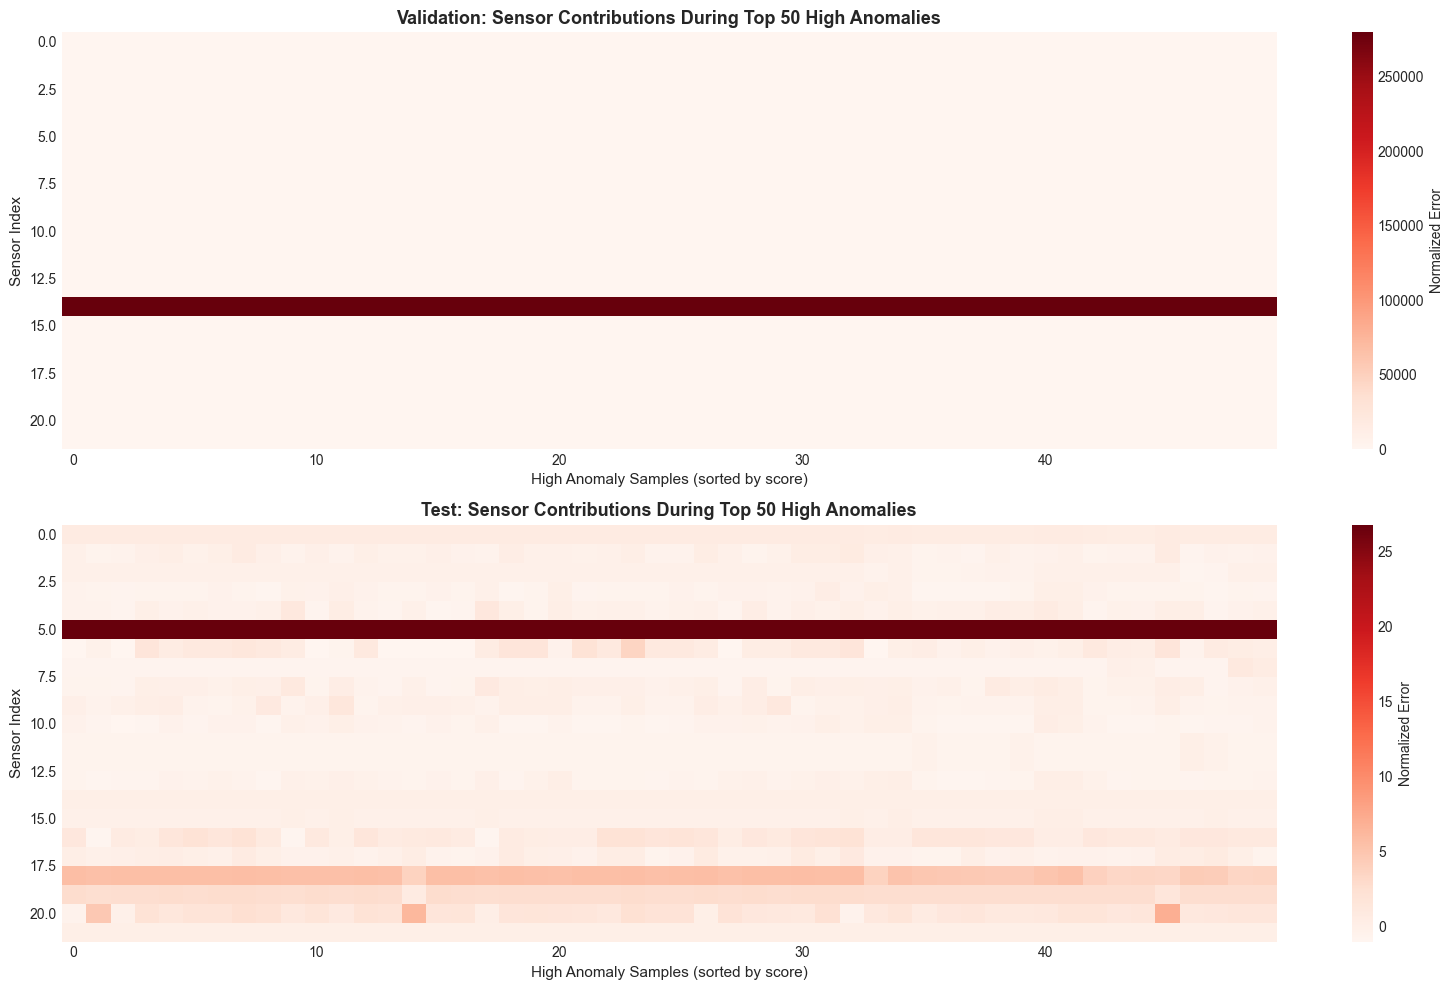

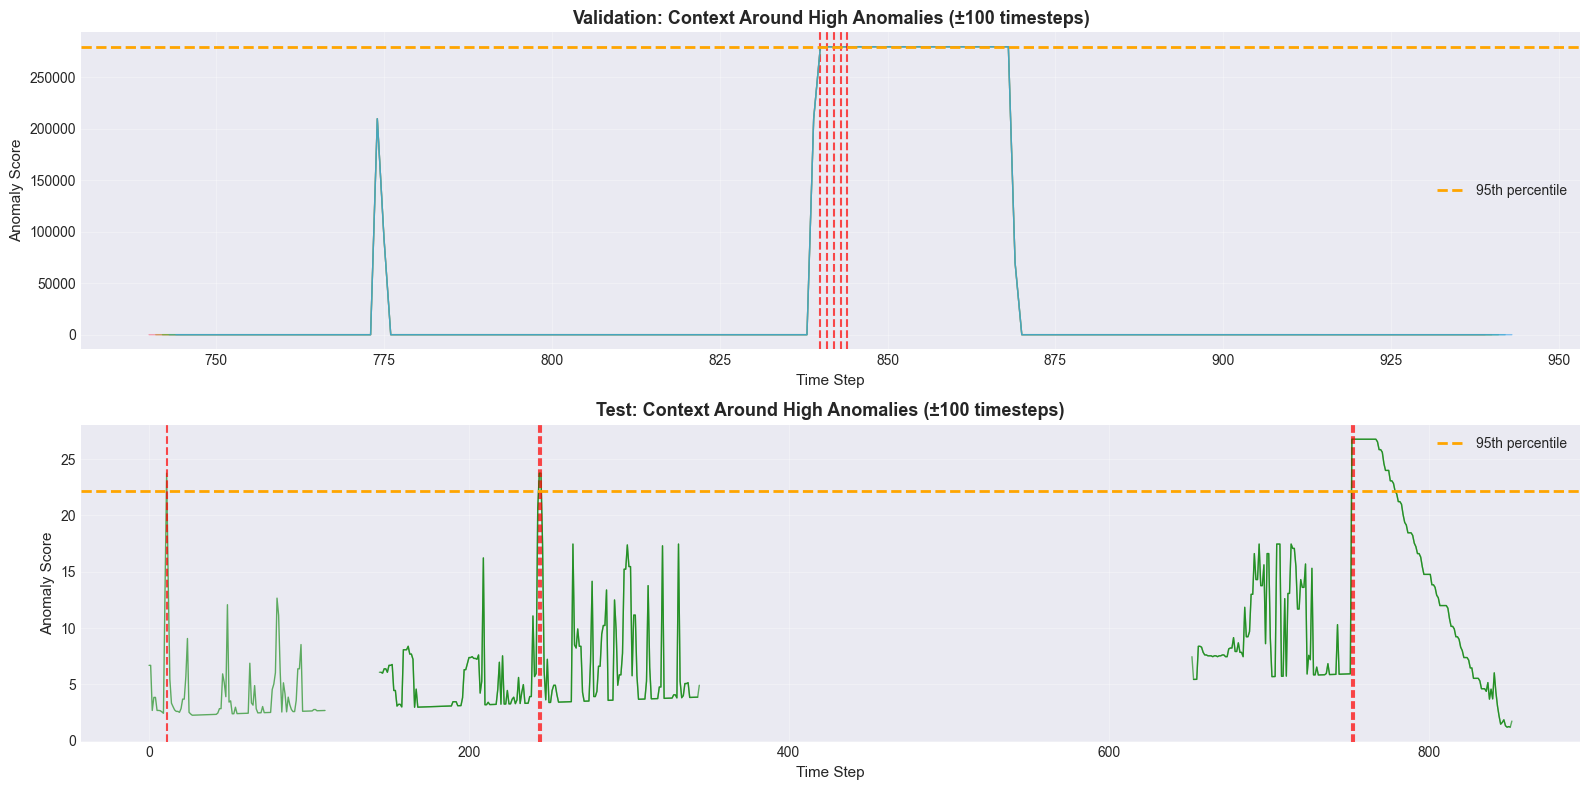

In [345]:
# Additional visualizations: Heatmap of sensor contributions during high anomalies
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Validation set heatmap
if len(high_anomaly_indices) > 0:
    # Get top 50 high anomaly samples for visualization
    top_anomalies_val = high_anomaly_indices[np.argsort(val_scores[high_anomaly_indices])[-50:][::-1]]
    heatmap_data_val = val_sensor_scores[top_anomalies_val].T
    
    im1 = axes[0].imshow(heatmap_data_val, aspect='auto', cmap='Reds', interpolation='nearest')
    axes[0].set_xlabel('High Anomaly Samples (sorted by score)', fontsize=11)
    axes[0].set_ylabel('Sensor Index', fontsize=11)
    axes[0].set_title('Validation: Sensor Contributions During Top 50 High Anomalies', fontsize=13, fontweight='bold')
    plt.colorbar(im1, ax=axes[0], label='Normalized Error')
    axes[0].grid(False)
else:
    axes[0].text(0.5, 0.5, 'No high anomalies found in validation set', 
                ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title('Validation: Sensor Contributions During High Anomalies', fontsize=13, fontweight='bold')

# Test set heatmap
if len(high_anomaly_indices_test) > 0:
    # Get top 50 high anomaly samples for visualization
    top_anomalies_test = high_anomaly_indices_test[np.argsort(test_scores[high_anomaly_indices_test])[-50:][::-1]]
    heatmap_data_test = test_sensor_scores[top_anomalies_test].T
    
    im2 = axes[1].imshow(heatmap_data_test, aspect='auto', cmap='Reds', interpolation='nearest')
    axes[1].set_xlabel('High Anomaly Samples (sorted by score)', fontsize=11)
    axes[1].set_ylabel('Sensor Index', fontsize=11)
    axes[1].set_title('Test: Sensor Contributions During Top 50 High Anomalies', fontsize=13, fontweight='bold')
    plt.colorbar(im2, ax=axes[1], label='Normalized Error')
    axes[1].grid(False)
else:
    axes[1].text(0.5, 0.5, 'No high anomalies found in test set', 
                ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].set_title('Test: Sensor Contributions During High Anomalies', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Zoomed-in view of anomaly scores around high anomaly regions
if len(high_anomaly_indices) > 0 or len(high_anomaly_indices_test) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    
    # Validation: Show context around high anomalies
    if len(high_anomaly_indices) > 0:
        window_size_viz = 100
        for idx in high_anomaly_indices[:5]:  # Show first 5 high anomalies
            start = max(0, idx - window_size_viz)
            end = min(len(val_scores), idx + window_size_viz)
            axes[0].plot(range(start, end), val_scores[start:end], alpha=0.6, linewidth=1)
            axes[0].axvline(x=idx, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].axhline(y=threshold_95, color='orange', linestyle='--', linewidth=2, label=f'95th percentile')
        axes[0].set_xlabel('Time Step', fontsize=11)
        axes[0].set_ylabel('Anomaly Score', fontsize=11)
        axes[0].set_title('Validation: Context Around High Anomalies (±100 timesteps)', fontsize=13, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # Test: Show context around high anomalies
    if len(high_anomaly_indices_test) > 0:
        window_size_viz = 100
        for idx in high_anomaly_indices_test[:5]:  # Show first 5 high anomalies
            start = max(0, idx - window_size_viz)
            end = min(len(test_scores), idx + window_size_viz)
            axes[1].plot(range(start, end), test_scores[start:end], alpha=0.6, linewidth=1, color='green')
            axes[1].axvline(x=idx, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[1].axhline(y=threshold_95_test, color='orange', linestyle='--', linewidth=2, label=f'95th percentile')
        axes[1].set_xlabel('Time Step', fontsize=11)
        axes[1].set_ylabel('Anomaly Score', fontsize=11)
        axes[1].set_title('Test: Context Around High Anomalies (±100 timesteps)', fontsize=13, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_28771/949657421.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([val_scores, test_scores], positions=[1, 2], widths=0.3,


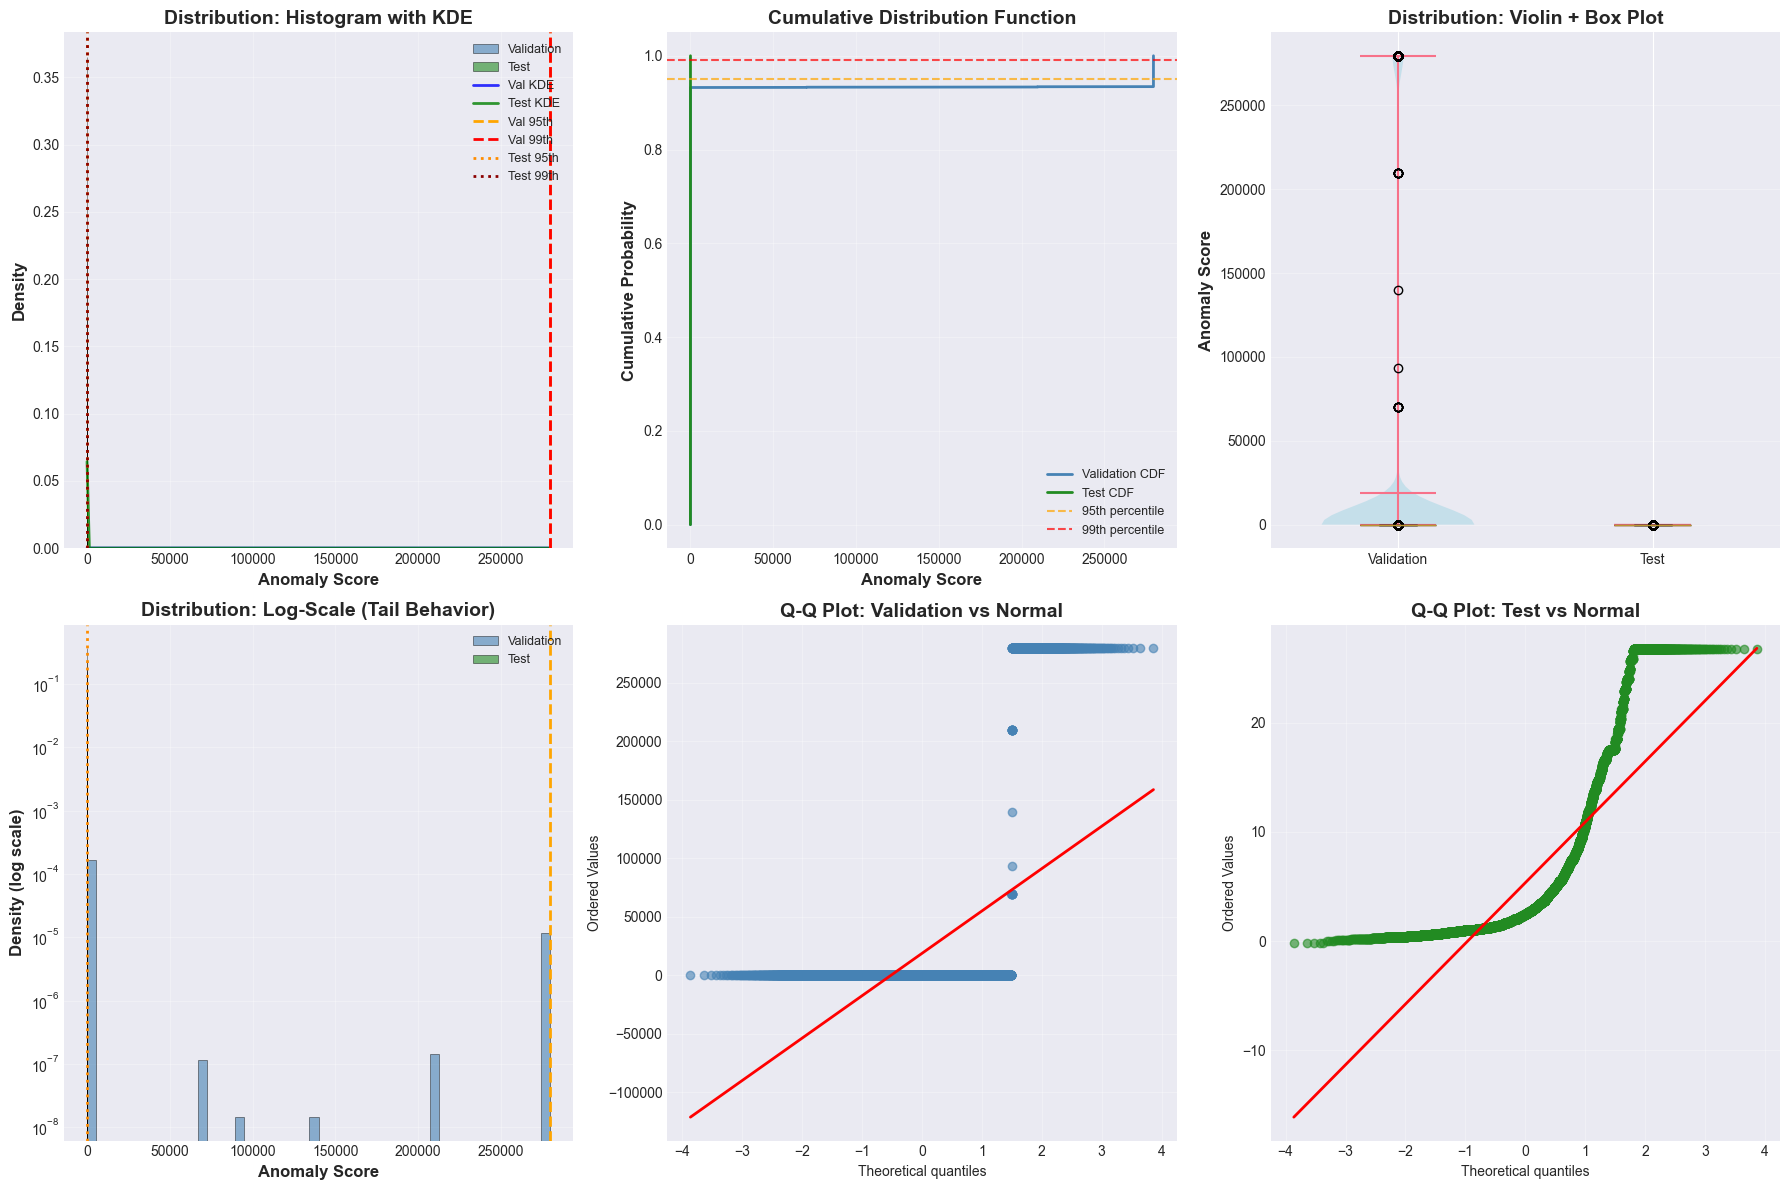


DETAILED DISTRIBUTION STATISTICS
         Metric  Validation    Test
          Count       12356   12357
           Mean  18702.9507  5.3408
         Median      1.6788  2.4615
        Std Dev  69676.3776  6.6061
            Min     -0.3759 -0.1667
            Max 279625.9667 26.7693
25th Percentile      1.1805  1.1667
75th Percentile      2.6666  6.3158
90th Percentile     15.9994 15.9231
95th Percentile 279619.6417 22.1539
99th Percentile 279620.4000 26.7693
       Skewness      3.4673  1.9266
       Kurtosis     10.0377  2.9469


In [346]:
# Focused Distribution Analysis of Anomaly Scores
from scipy import stats

fig = plt.figure(figsize=(18, 12))

# 1. Histogram with KDE overlay
ax1 = plt.subplot(2, 3, 1)
ax1.hist(val_scores, bins=50, alpha=0.6, label='Validation', density=True, color='steelblue', edgecolor='black', linewidth=0.5)
ax1.hist(test_scores, bins=50, alpha=0.6, label='Test', density=True, color='forestgreen', edgecolor='black', linewidth=0.5)

# Add KDE curves
try:
    from scipy.stats import gaussian_kde
    kde_val = gaussian_kde(val_scores)
    kde_test = gaussian_kde(test_scores)
    x_range = np.linspace(min(val_scores.min(), test_scores.min()), 
                         max(val_scores.max(), test_scores.max()), 200)
    ax1.plot(x_range, kde_val(x_range), 'b-', linewidth=2, label='Val KDE', alpha=0.8)
    ax1.plot(x_range, kde_test(x_range), 'g-', linewidth=2, label='Test KDE', alpha=0.8)
except:
    pass

# Add percentile lines
ax1.axvline(x=np.percentile(val_scores, 95), color='orange', linestyle='--', linewidth=2, label='Val 95th')
ax1.axvline(x=np.percentile(val_scores, 99), color='red', linestyle='--', linewidth=2, label='Val 99th')
ax1.axvline(x=np.percentile(test_scores, 95), color='darkorange', linestyle=':', linewidth=2, label='Test 95th')
ax1.axvline(x=np.percentile(test_scores, 99), color='darkred', linestyle=':', linewidth=2, label='Test 99th')

ax1.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution: Histogram with KDE', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Cumulative Distribution Function (CDF)
ax2 = plt.subplot(2, 3, 2)
sorted_val = np.sort(val_scores)
sorted_test = np.sort(test_scores)
y_val = np.arange(1, len (sorted_val) + 1) / len(sorted_val)
y_test = np.arange(1, len(sorted_test) + 1) / len(sorted_test)

ax2.plot(sorted_val, y_val, label='Validation CDF', linewidth=2, color='steelblue')
ax2.plot(sorted_test, y_test, label='Test CDF', linewidth=2, color='forestgreen')
ax2.axhline(y=0.95, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='95th percentile')
ax2.axhline(y=0.99, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='99th percentile')
ax2.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Box plot with violin plot overlay
ax3 = plt.subplot(2, 3, 3)
parts = ax3.violinplot([val_scores, test_scores], positions=[1, 2], widths=0.6, 
                       showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.6)

bp = ax3.boxplot([val_scores, test_scores], positions=[1, 2], widths=0.3, 
                 patch_artist=True, labels=['Validation', 'Test'])
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('forestgreen')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)

ax3.set_ylabel('Anomaly Score', fontsize=12, fontweight='bold')
ax3.set_title('Distribution: Violin + Box Plot', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Log-scale histogram (to see tail behavior)
ax4 = plt.subplot(2, 3, 4)
ax4.hist(val_scores, bins=50, alpha=0.6, label='Validation', density=True, color='steelblue', edgecolor='black', linewidth=0.5)
ax4.hist(test_scores, bins=50, alpha=0.6, label='Test', density=True, color='forestgreen', edgecolor='black', linewidth=0.5)
ax4.set_yscale('log')
ax4.axvline(x=np.percentile(val_scores, 95), color='orange', linestyle='--', linewidth=2)
ax4.axvline(x=np.percentile(test_scores, 95), color='darkorange', linestyle=':', linewidth=2)
ax4.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Density (log scale)', fontsize=12, fontweight='bold')
ax4.set_title('Distribution: Log-Scale (Tail Behavior)', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Q-Q plot (checking for normality)
ax5 = plt.subplot(2, 3, 5)
stats.probplot(val_scores, dist="norm", plot=ax5)
ax5.get_lines()[0].set_color('steelblue')
ax5.get_lines()[0].set_markerfacecolor('steelblue')
ax5.get_lines()[0].set_alpha(0.6)
ax5.get_lines()[1].set_color('red')
ax5.get_lines()[1].set_linewidth(2)
ax5.set_title('Q-Q Plot: Validation vs Normal', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Q-Q plot for test set
ax6 = plt.subplot(2, 3, 6)
stats.probplot(test_scores, dist="norm", plot=ax6)
ax6.get_lines()[0].set_color('forestgreen')
ax6.get_lines()[0].set_markerfacecolor('forestgreen')
ax6.get_lines()[0].set_alpha(0.6)
ax6.get_lines()[1].set_color('red')
ax6.get_lines()[1].set_linewidth(2)
ax6.set_title('Q-Q Plot: Test vs Normal', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed statistics table
print("\n" + "="*80)
print("DETAILED DISTRIBUTION STATISTICS")
print("="*80)

stats_data = {
    'Metric': ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max', 
               '25th Percentile', '75th Percentile', '90th Percentile', 
               '95th Percentile', '99th Percentile', 'Skewness', 'Kurtosis'],
    'Validation': [
        len(val_scores),
        f"{np.mean(val_scores):.4f}",
        f"{np.median(val_scores):.4f}",
        f"{np.std(val_scores):.4f}",
        f"{np.min(val_scores):.4f}",
        f"{np.max(val_scores):.4f}",
        f"{np.percentile(val_scores, 25):.4f}",
        f"{np.percentile(val_scores, 75):.4f}",
        f"{np.percentile(val_scores, 90):.4f}",
        f"{np.percentile(val_scores, 95):.4f}",
        f"{np.percentile(val_scores, 99):.4f}",
        f"{stats.skew(val_scores):.4f}",
        f"{stats.kurtosis(val_scores):.4f}"
    ],
    'Test': [
        len(test_scores),
        f"{np.mean(test_scores):.4f}",
        f"{np.median(test_scores):.4f}",
        f"{np.std(test_scores):.4f}",
        f"{np.min(test_scores):.4f}",
        f"{np.max(test_scores):.4f}",
        f"{np.percentile(test_scores, 25):.4f}",
        f"{np.percentile(test_scores, 75):.4f}",
        f"{np.percentile(test_scores, 90):.4f}",
        f"{np.percentile(test_scores, 95):.4f}",
        f"{np.percentile(test_scores, 99):.4f}",
        f"{stats.skew(test_scores):.4f}",
        f"{stats.kurtosis(test_scores):.4f}"
    ]
}

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))


Now let's add some anomalies

In [347]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary of related sensors for realistic multi-channel anomalies
RELATED_SENSORS = {
    "engine_performance": [
        "ENGINE RPM (RPM)",
        "THROTTLE ()",
        "ENGINE LOAD ()",
        "INTAKE MANIFOLD ABSOLUTE PRESSURE (kPa)"
    ],
    "thermal_system": [
        "ENGINE COOLANT TEMPERATURE (C)",
        "INTAKE AIR TEMPERATURE (C)",
        "AMBIENT AIR TEMPERATURE (C)"
    ],
    "fuel_system": [
        "LONG TERM FUEL TRIM BANK 1 ()",
        "SHORT TERM FUEL TRIM BANK 1 ()",
        "AIR FLOW RATE FROM MASS FLOW SENSOR (g/s)"
    ],
    "driver_inputs": [
        "THROTTLE ()",
        "ACCELERATOR PEDAL POSITION D ()",
        "ACCELERATOR PEDAL POSITION E ()",
        "ABSOLUTE THROTTLE POSITION ()"
    ],
    "drivetrain": [
        "VEHICLE SPEED SENSOR (km/h)",
        "ENGINE RPM (RPM)",
        "ENGINE LOAD ()"
    ]
}

def inject_vacuum_leak(data, column_names, anomaly_length=40):
    """Vacuum leak: fuel trim increases + manifold pressure decreases"""
    anomalous_data = data.copy()
    start_idx = np.random.randint(0, len(data) - anomaly_length)
    
    try:
        fuel_trim_idx = column_names.index("SHORT TERM FUEL TRIM BANK 1 ()")
        manifold_idx = column_names.index("INTAKE MANIFOLD ABSOLUTE PRESSURE (kPa)")
        
        for i in range(start_idx, start_idx + anomaly_length):
            anomalous_data[i, fuel_trim_idx] += 0.3 * np.abs(np.random.randn())
            anomalous_data[i, manifold_idx] *= 0.85
        
        return anomalous_data, start_idx, start_idx + anomaly_length, [fuel_trim_idx, manifold_idx]
    except ValueError:
        return None

def inject_overheating(data, column_names, anomaly_length=100):
    """Overheating: coolant temp rises + intake air temp rises"""
    anomalous_data = data.copy()
    start_idx = np.random.randint(0, len(data) - anomaly_length)
    
    try:
        coolant_idx = column_names.index("ENGINE COOLANT TEMPERATURE (C)")
        intake_air_idx = column_names.index("INTAKE AIR TEMPERATURE (C)")
        
        for i in range(start_idx, start_idx + anomaly_length):
            progress = (i - start_idx) / anomaly_length
            anomalous_data[i, coolant_idx] += 15 * progress
            anomalous_data[i, intake_air_idx] += 5 * progress
        
        return anomalous_data, start_idx, start_idx + anomaly_length, [coolant_idx, intake_air_idx]
    except ValueError:
        return None

def inject_throttle_mismatch(data, column_names, anomaly_length=25):
    """Throttle mismatch: throttle reading doesn't match pedal position"""
    anomalous_data = data.copy()
    start_idx = np.random.randint(0, len(data) - anomaly_length)
    
    try:
        throttle_idx = column_names.index("THROTTLE ()")
        pedal_idx = column_names.index("ACCELERATOR PEDAL POSITION D ()")
        
        for i in range(start_idx, start_idx + anomaly_length):
            anomalous_data[i, throttle_idx] += 0.2 * np.random.randn()
        
        return anomalous_data, start_idx, start_idx + anomaly_length, [throttle_idx, pedal_idx]
    except ValueError:
        return None

def inject_intake_restriction(data, column_names, anomaly_length=60):
    """Clogged air filter: MAF drops + manifold pressure drops + load increases"""
    anomalous_data = data.copy()
    start_idx = np.random.randint(0, len(data) - anomaly_length)
    
    try:
        maf_idx = column_names.index("AIR FLOW RATE FROM MASS FLOW SENSOR (g/s)")
        manifold_idx = column_names.index("INTAKE MANIFOLD ABSOLUTE PRESSURE (kPa)")
        load_idx = column_names.index("ENGINE LOAD ()")
        
        for i in range(start_idx, start_idx + anomaly_length):
            anomalous_data[i, maf_idx] *= 0.75
            anomalous_data[i, manifold_idx] *= 0.80
            anomalous_data[i, load_idx] *= 1.15
        
        return anomalous_data, start_idx, start_idx + anomaly_length, [maf_idx, manifold_idx, load_idx]
    except ValueError:
        return None

def inject_spike_anomaly(data, sensor_idx, anomaly_length=10, magnitude=3.0):
    """Sharp spike in single sensor"""
    anomalous_data = data.copy()
    start_idx = np.random.randint(0, len(data) - anomaly_length)
    
    for i in range(start_idx, start_idx + anomaly_length):
        anomalous_data[i, sensor_idx] *= (1 + magnitude * np.random.randn())
    
    return anomalous_data, start_idx, start_idx + anomaly_length

def inject_drift_anomaly(data, sensor_idx, anomaly_length=50, drift_rate=0.05):
    """Gradual drift in single sensor"""
    anomalous_data = data.copy()
    start_idx = np.random.randint(0, len(data) - anomaly_length)
    
    for i in range(start_idx, start_idx + anomaly_length):
        drift_amount = drift_rate * (i - start_idx) * anomalous_data[start_idx, sensor_idx]
        anomalous_data[i, sensor_idx] += drift_amount
    
    return anomalous_data, start_idx, start_idx + anomaly_length

def inject_stuck_anomaly(data, sensor_idx, anomaly_length=30):
    """Sensor stuck at constant value"""
    anomalous_data = data.copy()
    start_idx = np.random.randint(0, len(data) - anomaly_length)
    stuck_value = anomalous_data[start_idx, sensor_idx]
    
    for i in range(start_idx, start_idx + anomaly_length):
        anomalous_data[i, sensor_idx] = stuck_value
    
    return anomalous_data, start_idx, start_idx + anomaly_length

In [348]:
def inject_balanced_anomalies(test_data, target_anomaly_rate=0.05, column_names=None):
    """
    Inject anomalies targeting a specific percentage of TIMESTEPS, not sequences
    
    Args:
        test_data: Clean test data
        target_anomaly_rate: Target % of timesteps to be anomalous (e.g., 0.05 = 5%)
        column_names: List of sensor names
    
    Returns:
        anomalous_data, labels, anomaly_info
    """
    n_samples = len(test_data)
    n_features = test_data.shape[1]
    
    # Calculate target timesteps to cover
    target_anomalous_timesteps = int(n_samples * target_anomaly_rate)
    
    print(f"Target: {target_anomaly_rate:.0%} of {n_samples} timesteps = {target_anomalous_timesteps} timesteps")
    
    # Define anomaly types with their typical lengths
    anomaly_configs = [
        {'type': 'spike', 'length': 10, 'weight': 0.3},
        {'type': 'drift', 'length': 50, 'weight': 0.4},
        {'type': 'stuck', 'length': 30, 'weight': 0.3}
    ]
    
    # Estimate how many sequences we can inject
    avg_length = sum(cfg['length'] * cfg['weight'] for cfg in anomaly_configs)
    n_sequences_to_inject = int(target_anomalous_timesteps / avg_length)
    
    print(f"Will inject approximately {n_sequences_to_inject} sequences (avg length {avg_length:.1f})")
    
    # Initialize
    test_data_anomalous = test_data.copy()
    labels = np.zeros(n_samples)
    anomaly_info = []
    
    injected_timesteps = 0
    sequence_count = 0
    attempts = 0
    max_attempts = n_sequences_to_inject * 3  # Prevent infinite loop
    
    while injected_timesteps < target_anomalous_timesteps and attempts < max_attempts:
        attempts += 1
        
        # Select anomaly type based on weights
        anomaly_type = np.random.choice(
            [cfg['type'] for cfg in anomaly_configs],
            p=[cfg['weight'] for cfg in anomaly_configs]
        )
        
        # Get corresponding config
        config = next(cfg for cfg in anomaly_configs if cfg['type'] == anomaly_type)
        anomaly_length = config['length']
        
        # Check if we have room for this anomaly
        if injected_timesteps + anomaly_length > target_anomalous_timesteps:
            # Try shorter anomaly
            anomaly_length = min(anomaly_length, target_anomalous_timesteps - injected_timesteps)
            if anomaly_length < 5:  # Too short to be meaningful
                break
        
        # Random start position (ensure we have room)
        if n_samples - anomaly_length < 10:
            break
        start_idx = np.random.randint(0, n_samples - anomaly_length)
        
        # Check for overlap with existing anomalies (optional: allow some overlap)
        if np.sum(labels[start_idx:start_idx + anomaly_length]) > 0.5 * anomaly_length:
            continue  # Skip if >50% overlap
        
        # Select random sensor(s) to affect
        n_sensors_affected = np.random.randint(1, min(4, n_features))
        affected_sensors = np.random.choice(n_features, n_sensors_affected, replace=False)
        
        # Inject anomaly
        if anomaly_type == 'spike':
            for sensor_idx in affected_sensors:
                spike_magnitude = np.random.uniform(3, 8)
                test_data_anomalous[start_idx:start_idx + anomaly_length, sensor_idx] += spike_magnitude
                
        elif anomaly_type == 'drift':
            for sensor_idx in affected_sensors:
                drift_rate = np.random.uniform(0.05, 0.2)
                drift = np.linspace(0, drift_rate * anomaly_length, anomaly_length)
                test_data_anomalous[start_idx:start_idx + anomaly_length, sensor_idx] += drift
                
        elif anomaly_type == 'stuck':
            for sensor_idx in affected_sensors:
                stuck_value = test_data_anomalous[start_idx, sensor_idx]
                test_data_anomalous[start_idx:start_idx + anomaly_length, sensor_idx] = stuck_value
        
        # Mark labels
        labels[start_idx:start_idx + anomaly_length] = 1
        
        # Record info
        anomaly_info.append({
            'type': anomaly_type,
            'start': start_idx,
            'end': start_idx + anomaly_length,
            'length': anomaly_length,
            'affected_sensors': affected_sensors.tolist(),
            'sensor_names': [column_names[i] if column_names else f"Sensor_{i}" 
                           for i in affected_sensors]
        })
        
        injected_timesteps += anomaly_length
        sequence_count += 1
    
    actual_anomaly_rate = np.sum(labels) / n_samples
    
    print(f"\n✓ Injection complete:")
    print(f"  Sequences injected: {sequence_count}")
    print(f"  Timesteps affected: {int(np.sum(labels))} / {n_samples}")
    print(f"  Actual anomaly rate: {actual_anomaly_rate:.1%}")
    print(f"  Target anomaly rate: {target_anomaly_rate:.1%}")
    
    # Print type distribution
    type_counts = {}
    for info in anomaly_info:
        type_counts[info['type']] = type_counts.get(info['type'], 0) + 1
    
    print(f"\nAnomaly Type Distribution:")
    for anom_type, count in type_counts.items():
        print(f"  - {anom_type}: {count} sequences")
    
    return test_data_anomalous, labels, anomaly_info

In [349]:
test_data_scaled_anomalies = test_data_scaled.copy()

test_data_scaled_anomalies, anomaly_labels, anomaly_info = inject_realistic_anomalies(
    data=test_data_scaled_anomalies,
    column_names=data.columns.tolist(),
    anomaly_percentage=0.10,  # 10% anomalies
    num_channels_range=(1, 1),  # 1-3 channels affected
    seed=42
)


print("Anomaly info:")
for i, info in enumerate(anomaly_info[:3]):
    print(f"\\nAnomaly {i+1}:")
    print(f"  Type: {info['type']}")
    print(f"  Time range: {info['start']} - {info['end']} (length: {info['length']})")
    print(f"  Affected sensors ({info['num_sensors']}): {', '.join(info['sensors'])}")

Injecting 1236 anomalous sequences into 12362 samples...
Target anomaly percentage: 10.0%\n
✓ Injected 1236 anomalous sequences
✓ Total anomalous samples: 11783 / 12362
✓ Actual anomaly percentage: 95.32%
\nAnomaly Type Distribution:
  - drift: 406
  - spike: 390
  - stuck: 440
Anomaly info:
\nAnomaly 1:
  Type: spike
  Time range: 5191 - 5201 (length: 10)
  Affected sensors (1): ABSOLUTE_BAROMETRIC_PRESSURE ()
\nAnomaly 2:
  Type: stuck
  Time range: 2047 - 2077 (length: 30)
  Affected sensors (1): FUEL_TANK ()
\nAnomaly 3:
  Type: stuck
  Time range: 3005 - 3035 (length: 30)
  Affected sensors (1): ABSOLUTE_BAROMETRIC_PRESSURE ()


In [350]:
X_test_anomalous, y_test_anomalous = create_sliding_windows(test_data_scaled_anomalies, window_size)

X_test_anomalous_tensor = torch.FloatTensor(X_test_anomalous)
y_test_anomalous_tensor = torch.FloatTensor(y_test_anomalous)

test_anomalous_dataset = TensorDataset(X_test_anomalous_tensor, y_test_anomalous_tensor)
test_anomalous_loader = DataLoader(
    test_anomalous_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

anomaly_labels_windowed = anomaly_labels[window_size:]

print(f"X_test_anomalous shape: {X_test_anomalous.shape}")
print(f"Anomaly labels shape: {anomaly_labels_windowed.shape}")

X_test_anomalous shape: (12357, 22, 5)
Anomaly labels shape: (12357,)


In [351]:
print("Computing anomaly scores on test set with injected anomalies...")
test_scores_anomalous, test_sensor_scores_anomalous, test_errors_anomalous = compute_anomaly_scores(
    model, test_anomalous_loader, device
)

print("\nAnomaly score statistics:")
print(f"  Mean: {np.mean(test_scores_anomalous):.4f}")
print(f"  Std: {np.std(test_scores_anomalous):.4f}")
print(f"  Min: {np.min(test_scores_anomalous):.4f}")
print(f"  Max: {np.max(test_scores_anomalous):.4f}")


Computing anomaly scores on test set with injected anomalies...

Anomaly score statistics:
  Mean: 4.8421
  Std: 6.5155
  Min: -0.2857
  Max: 102.2770


Normal samples: 574
Anomaly samples: 11783

Normal score statistics:
  Mean: 3.5584, Median: 1.5643
  Std: 4.5662, Min: -0.2857, Max: 19.3332

Anomaly score statistics:
  Mean: 4.9046, Median: 2.8500
  Std: 6.5894, Min: 0.0000, Max: 102.2770


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_28771/1354754306.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([normal_scores, anomaly_scores], labels=['Normal', 'Anomaly'],


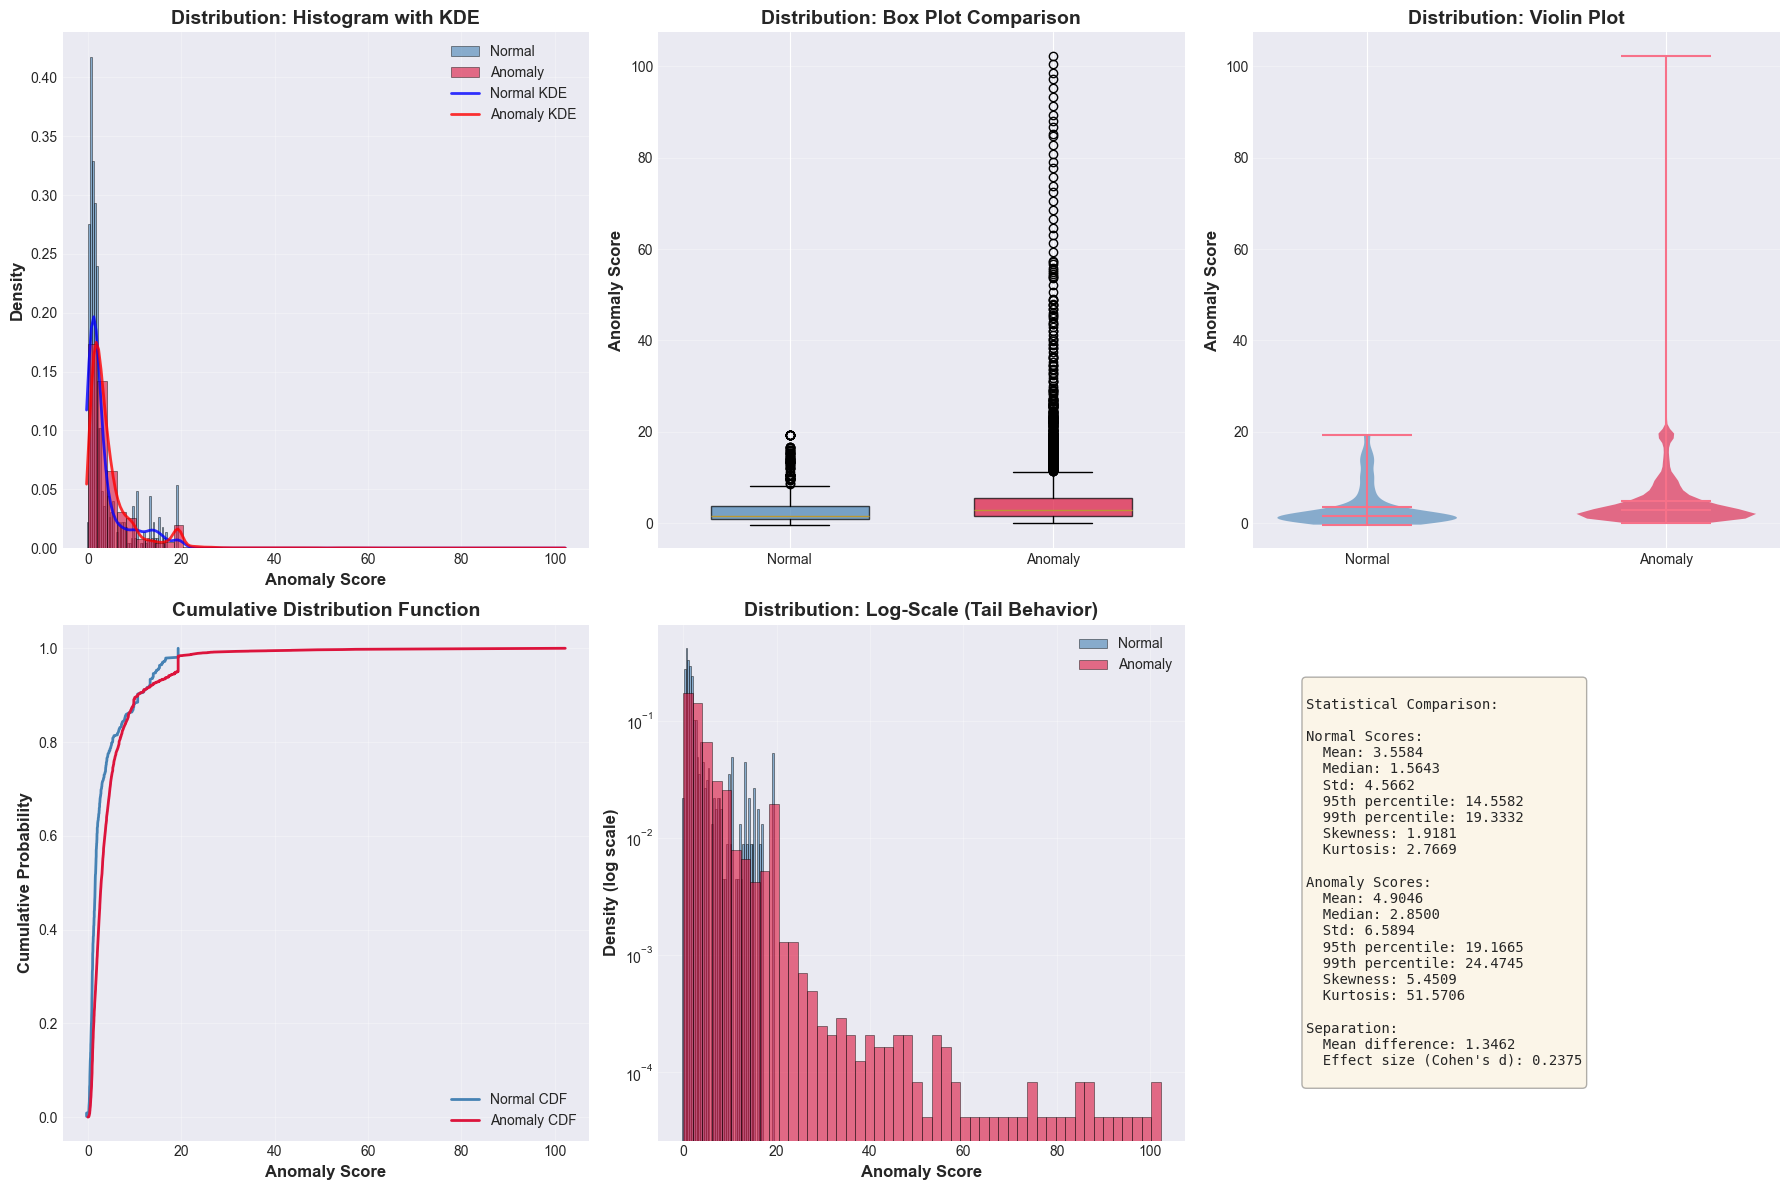

In [352]:
# Distribution Visualization: Anomaly vs Normal Scores
from scipy import stats

# Separate scores by label
normal_scores = test_scores_anomalous[anomaly_labels_windowed == 0]
anomaly_scores = test_scores_anomalous[anomaly_labels_windowed == 1]

print(f"Normal samples: {len(normal_scores)}")
print(f"Anomaly samples: {len(anomaly_scores)}")
print(f"\nNormal score statistics:")
print(f"  Mean: {np.mean(normal_scores):.4f}, Median: {np.median(normal_scores):.4f}")
print(f"  Std: {np.std(normal_scores):.4f}, Min: {np.min(normal_scores):.4f}, Max: {np.max(normal_scores):.4f}")
print(f"\nAnomaly score statistics:")
print(f"  Mean: {np.mean(anomaly_scores):.4f}, Median: {np.median(anomaly_scores):.4f}")
print(f"  Std: {np.std(anomaly_scores):.4f}, Min: {np.min(anomaly_scores):.4f}, Max: {np.max(anomaly_scores):.4f}")

# Create comprehensive distribution comparison
fig = plt.figure(figsize=(18, 12))

# 1. Histogram comparison
ax1 = plt.subplot(2, 3, 1)
ax1.hist(normal_scores, bins=50, alpha=0.6, label='Normal', density=True, 
         color='steelblue', edgecolor='black', linewidth=0.5)
ax1.hist(anomaly_scores, bins=50, alpha=0.6, label='Anomaly', density=True, 
         color='crimson', edgecolor='black', linewidth=0.5)

# Add KDE curves
try:
    from scipy.stats import gaussian_kde
    kde_normal = gaussian_kde(normal_scores)
    kde_anomaly = gaussian_kde(anomaly_scores)
    x_range = np.linspace(min(normal_scores.min(), anomaly_scores.min()), 
                         max(normal_scores.max(), anomaly_scores.max()), 200)
    ax1.plot(x_range, kde_normal(x_range), 'b-', linewidth=2, label='Normal KDE', alpha=0.8)
    ax1.plot(x_range, kde_anomaly(x_range), 'r-', linewidth=2, label='Anomaly KDE', alpha=0.8)
except:
    pass

ax1.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution: Histogram with KDE', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Box plot comparison
ax2 = plt.subplot(2, 3, 2)
bp = ax2.boxplot([normal_scores, anomaly_scores], labels=['Normal', 'Anomaly'], 
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('crimson')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
ax2.set_ylabel('Anomaly Score', fontsize=12, fontweight='bold')
ax2.set_title('Distribution: Box Plot Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Violin plot
ax3 = plt.subplot(2, 3, 3)
parts = ax3.violinplot([normal_scores, anomaly_scores], positions=[1, 2], 
                       widths=0.6, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor('steelblue' if i == 0 else 'crimson')
    pc.set_alpha(0.6)
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Normal', 'Anomaly'])
ax3.set_ylabel('Anomaly Score', fontsize=12, fontweight='bold')
ax3.set_title('Distribution: Violin Plot', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Cumulative Distribution Function (CDF)
ax4 = plt.subplot(2, 3, 4)
sorted_normal = np.sort(normal_scores)
sorted_anomaly = np.sort(anomaly_scores)
y_normal = np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)
y_anomaly = np.arange(1, len(sorted_anomaly) + 1) / len(sorted_anomaly)

ax4.plot(sorted_normal, y_normal, label='Normal CDF', linewidth=2, color='steelblue')
ax4.plot(sorted_anomaly, y_anomaly, label='Anomaly CDF', linewidth=2, color='crimson')
ax4.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax4.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax4.legend(loc='lower right', fontsize=10)
ax4.grid(True, alpha=0.3)

# 5. Log-scale histogram (to see tail behavior)
ax5 = plt.subplot(2, 3, 5)
ax5.hist(normal_scores, bins=50, alpha=0.6, label='Normal', density=True, 
         color='steelblue', edgecolor='black', linewidth=0.5)
ax5.hist(anomaly_scores, bins=50, alpha=0.6, label='Anomaly', density=True, 
         color='crimson', edgecolor='black', linewidth=0.5)
ax5.set_yscale('log')
ax5.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax5.set_ylabel('Density (log scale)', fontsize=12, fontweight='bold')
ax5.set_title('Distribution: Log-Scale (Tail Behavior)', fontsize=14, fontweight='bold')
ax5.legend(loc='upper right', fontsize=10)
ax5.grid(True, alpha=0.3)

# 6. Statistical comparison
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Calculate statistics
stats_text = f"""
Statistical Comparison:

Normal Scores:
  Mean: {np.mean(normal_scores):.4f}
  Median: {np.median(normal_scores):.4f}
  Std: {np.std(normal_scores):.4f}
  95th percentile: {np.percentile(normal_scores, 95):.4f}
  99th percentile: {np.percentile(normal_scores, 99):.4f}
  Skewness: {stats.skew(normal_scores):.4f}
  Kurtosis: {stats.kurtosis(normal_scores):.4f}

Anomaly Scores:
  Mean: {np.mean(anomaly_scores):.4f}
  Median: {np.median(anomaly_scores):.4f}
  Std: {np.std(anomaly_scores):.4f}
  95th percentile: {np.percentile(anomaly_scores, 95):.4f}
  99th percentile: {np.percentile(anomaly_scores, 99):.4f}
  Skewness: {stats.skew(anomaly_scores):.4f}
  Kurtosis: {stats.kurtosis(anomaly_scores):.4f}

Separation:
  Mean difference: {np.mean(anomaly_scores) - np.mean(normal_scores):.4f}
  Effect size (Cohen's d): {(np.mean(anomaly_scores) - np.mean(normal_scores)) / np.sqrt((np.var(normal_scores) + np.var(anomaly_scores)) / 2):.4f}
"""

ax6.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


In [353]:
# Evaluate detection performance with F2-optimized threshold
from sklearn.metrics import precision_recall_fscore_support, average_precision_score, fbeta_score
from sklearn.metrics import confusion_matrix, roc_auc_score
import numpy as np

def compute_fbeta_score(precision, recall, beta=2):
    """Compute F-beta score (beta=2 prioritizes recall)"""
    if precision + recall == 0:
        return 0
    return (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

def find_optimal_threshold(scores, labels, beta=2, search_range=(5, 99.9)):
    """
    Find threshold that maximizes F-beta score
    
    Args:
        scores: Anomaly scores
        labels: Ground truth labels
        beta: F-beta parameter (2 = prioritize recall 2x over precision)
        search_range: (min_percentile, max_percentile) to search
    
    Returns:
        best_threshold, best_fbeta, best_metrics_dict
    """
    # Create candidate thresholds across percentile range
    percentiles = np.linspace(search_range[0], search_range[1], 200)
    thresholds = np.percentile(scores, percentiles)
    
    best_fbeta = 0
    best_threshold = None
    best_metrics = None
    best_percentile = None
    
    print(f"Searching for optimal threshold (F{beta} score)...")
    print("="*70)
    
    for percentile, threshold in zip(percentiles, thresholds):
        predictions = (scores >= threshold).astype(int)
        
        # Compute metrics
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, predictions, average='binary', zero_division=0
        )
        
        # Compute F-beta
        fbeta = compute_fbeta_score(precision, recall, beta)
        
        # Track best
        if fbeta > best_fbeta:
            best_fbeta = fbeta
            best_threshold = threshold
            best_percentile = percentile
            
            tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
            
            best_metrics = {
                'percentile': percentile,
                'threshold': threshold,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'f2': fbeta,
                'tp': tp,
                'fp': fp,
                'tn': tn,
                'fn': fn
            }
    
    print(f"✓ Optimal threshold found at {best_percentile:.1f}th percentile")
    print(f"  Threshold value: {best_threshold:.4f}")
    print(f"  F2-Score: {best_fbeta:.3f}")
    print(f"  Precision: {best_metrics['precision']:.3f}")
    print(f"  Recall: {best_metrics['recall']:.3f}")
    print("="*70)
    
    return best_threshold, best_fbeta, best_metrics


# ============================================================================
# OPTIMIZED THRESHOLD SELECTION
# ============================================================================

print("\n" + "="*70)
print("F2-OPTIMIZED THRESHOLD SELECTION")
print("="*70)

# Find optimal threshold using F2 score
optimal_threshold, optimal_f2, optimal_metrics = find_optimal_threshold(
    test_scores_anomalous, 
    anomaly_labels_windowed,
    beta=2,  # Prioritize recall 2x over precision
    search_range=(5, 99.9)  # Search from 5th to 99.9th percentile
)

# Make predictions with optimal threshold
predictions_optimal = (test_scores_anomalous >= optimal_threshold).astype(int)


# ============================================================================
# COMPARISON WITH FIXED PERCENTILES
# ============================================================================

print("\n" + "="*70)
print("COMPARISON: F2-OPTIMIZED vs FIXED PERCENTILES")
print("="*70)

# Test fixed percentiles for comparison
thresholds_to_test = [90, 95, 99]
results = []

# Add optimal result first
results.append({
    'method': f'F2-Optimized ({optimal_metrics["percentile"]:.1f}th percentile)',
    'threshold': optimal_threshold,
    'precision': optimal_metrics['precision'],
    'recall': optimal_metrics['recall'],
    'f1': optimal_metrics['f1'],
    'f2': optimal_metrics['f2'],
    'tp': optimal_metrics['tp'],
    'fp': optimal_metrics['fp'],
    'tn': optimal_metrics['tn'],
    'fn': optimal_metrics['fn']
})

# Compare with fixed percentiles
for percentile in thresholds_to_test:
    threshold = np.percentile(test_scores_anomalous, percentile)
    predictions = (test_scores_anomalous >= threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        anomaly_labels_windowed, predictions, average='binary', zero_division=0
    )
    
    f2 = compute_fbeta_score(precision, recall, beta=2)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(anomaly_labels_windowed, predictions).ravel()
    
    results.append({
        'method': f'{percentile}th percentile',
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'f2': f2,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

# Print comparison table
print(f"\n{'Method':<35} {'Precision':<12} {'Recall':<12} {'F1':<12} {'F2':<12}")
print("-"*83)
for result in results:
    print(f"{result['method']:<35} "
          f"{result['precision']:<12.3f} "
          f"{result['recall']:<12.3f} "
          f"{result['f1']:<12.3f} "
          f"{result['f2']:<12.3f}")

print("\n" + "="*70)
print("DETAILED METRICS FOR OPTIMAL THRESHOLD")
print("="*70)
print(f"\nThreshold: {optimal_threshold:.4f} ({optimal_metrics['percentile']:.1f}th percentile)")
print(f"  Precision: {optimal_metrics['precision']:.3f}")
print(f"  Recall: {optimal_metrics['recall']:.3f}")
print(f"  F1-Score: {optimal_metrics['f1']:.3f}")
print(f"  F2-Score: {optimal_metrics['f2']:.3f}")
print(f"\nConfusion Matrix:")
print(f"  True Positives (TP):  {optimal_metrics['tp']:>6}")
print(f"  False Positives (FP): {optimal_metrics['fp']:>6}")
print(f"  True Negatives (TN):  {optimal_metrics['tn']:>6}")
print(f"  False Negatives (FN): {optimal_metrics['fn']:>6}")
print(f"\n  Detection Rate: {optimal_metrics['tp']/(optimal_metrics['tp']+optimal_metrics['fn']):.1%}")
print(f"  False Alarm Rate: {optimal_metrics['fp']/(optimal_metrics['fp']+optimal_metrics['tn']):.1%}")


# ============================================================================
# ADDITIONAL METRICS
# ============================================================================

print("\n" + "="*70)
print("ADDITIONAL PERFORMANCE METRICS")
print("="*70)

# ROC-AUC
try:
    auc = roc_auc_score(anomaly_labels_windowed, test_scores_anomalous)
    print(f"AUC-ROC: {auc:.3f}")
except Exception as e:
    print(f"AUC-ROC: Could not compute ({str(e)})")

# Average Precision (PR-AUC)
try:
    avg_precision = average_precision_score(anomaly_labels_windowed, test_scores_anomalous)
    print(f"Average Precision (PR-AUC): {avg_precision:.3f}")
except Exception as e:
    print(f"Average Precision: Could not compute ({str(e)})")

# Improvement metrics
if len(results) > 1:
    baseline_95th = results[2]  # 95th percentile result
    improvement_recall = (optimal_metrics['recall'] - baseline_95th['recall']) / baseline_95th['recall'] * 100
    improvement_f2 = (optimal_metrics['f2'] - baseline_95th['f2']) / baseline_95th['f2'] * 100
    
    print(f"\n{'='*70}")
    print("IMPROVEMENT vs 95th PERCENTILE BASELINE")
    print("="*70)
    print(f"Recall improvement: {improvement_recall:+.1f}%")
    print(f"F2 improvement: {improvement_f2:+.1f}%")
    print(f"Additional anomalies detected: {optimal_metrics['tp'] - baseline_95th['tp']}")



F2-OPTIMIZED THRESHOLD SELECTION
Searching for optimal threshold (F2 score)...
✓ Optimal threshold found at 5.0th percentile
  Threshold value: 0.6608
  F2-Score: 0.956
  Precision: 0.959
  Recall: 0.955

COMPARISON: F2-OPTIMIZED vs FIXED PERCENTILES

Method                              Precision    Recall       F1           F2          
-----------------------------------------------------------------------------------
F2-Optimized (5.0th percentile)     0.959        0.955        0.957        0.956       
90th percentile                     0.951        0.100        0.181        0.122       
95th percentile                     0.981        0.052        0.098        0.064       
99th percentile                     1.000        0.011        0.021        0.013       

DETAILED METRICS FOR OPTIMAL THRESHOLD

Threshold: 0.6608 (5.0th percentile)
  Precision: 0.959
  Recall: 0.955
  F1-Score: 0.957
  F2-Score: 0.956

Confusion Matrix:
  True Positives (TP):   11258
  False Positives (FP): 

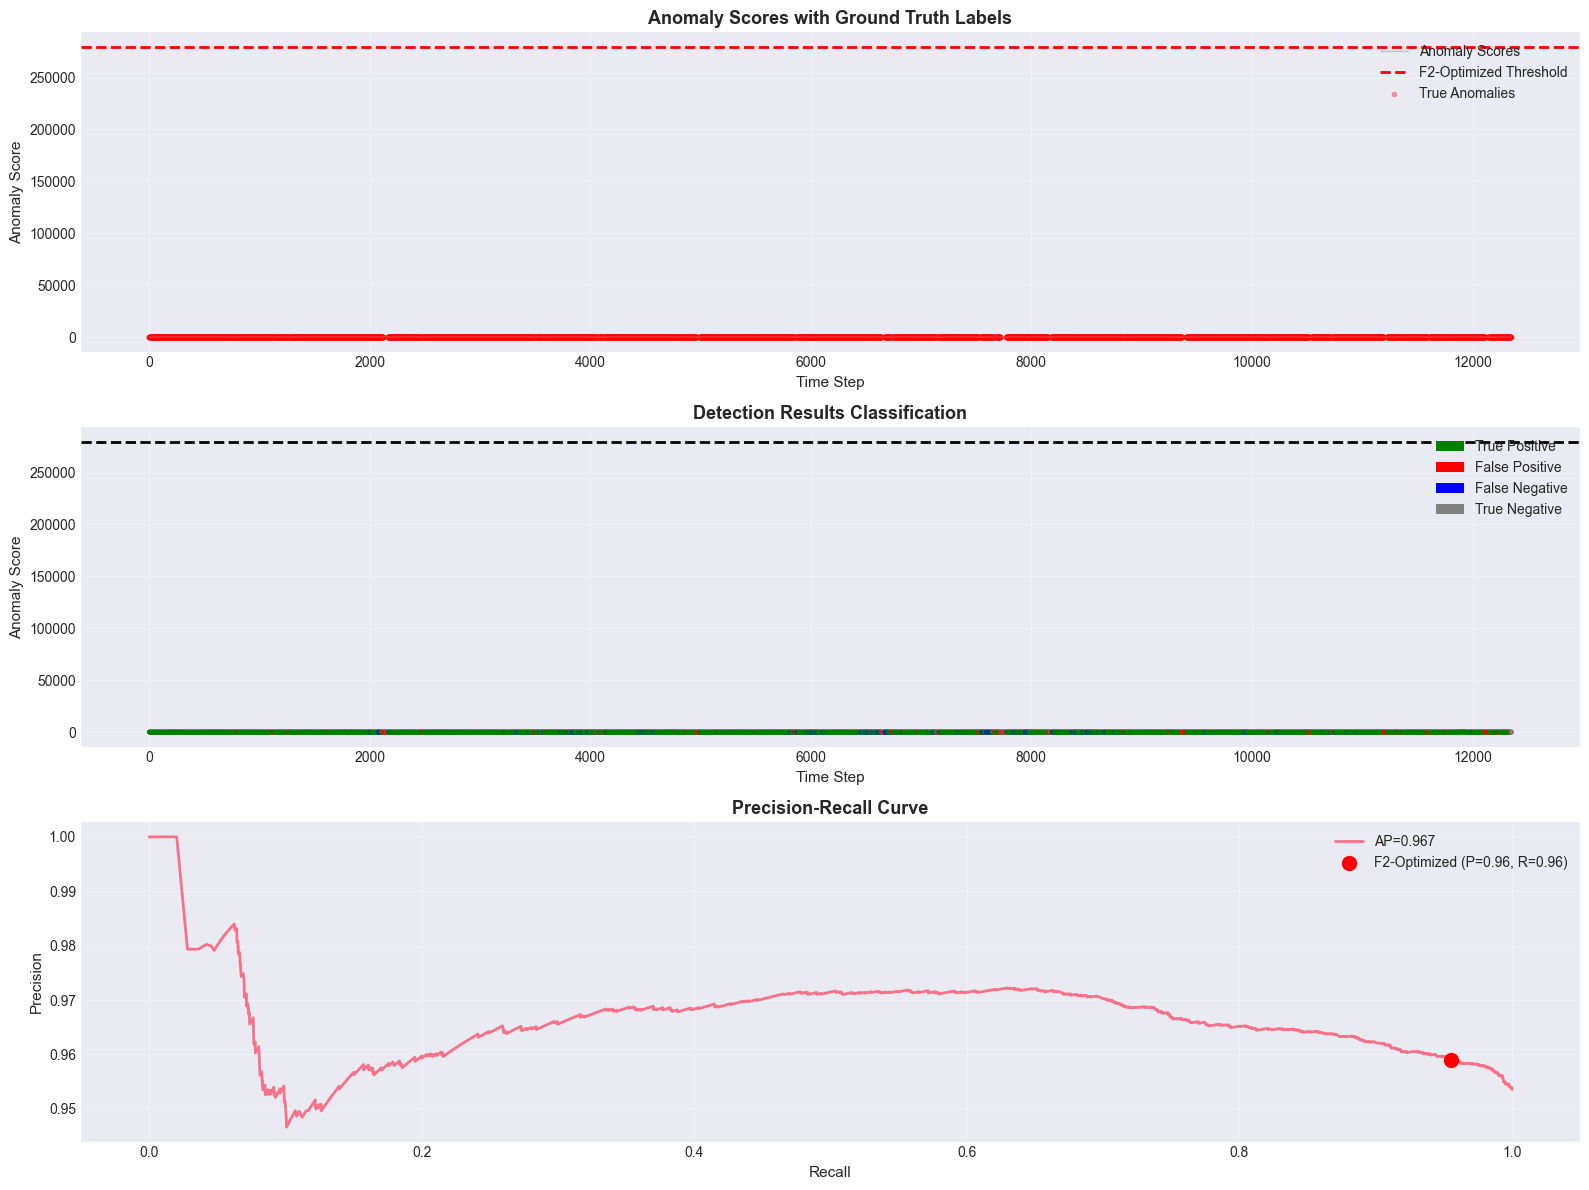

In [354]:
from sklearn.metrics import precision_recall_curve
# Visualization: Detection results and performance curves
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Anomaly scores with ground truth
axes[0].plot(test_scores_anomalous, alpha=0.6, linewidth=0.8, label='Anomaly Scores')
axes[0].axhline(y=threshold_95, color='red', linestyle='--', linewidth=2, label='F2-Optimized Threshold')

# Highlight true anomalies
anomaly_regions = np.where(anomaly_labels_windowed == 1)[0]
if len(anomaly_regions) > 0:
    axes[0].scatter(anomaly_regions, test_scores_anomalous[anomaly_regions], 
                   color='red', s=10, alpha=0.3, label='True Anomalies')

axes[0].set_xlabel('Time Step', fontsize=11)
axes[0].set_ylabel('Anomaly Score', fontsize=11)
axes[0].set_title('Anomaly Scores with Ground Truth Labels', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Detection results (TP, FP, TN, FN)
colors = ['green' if pred == 1 and true == 1 else 
          'red' if pred == 1 and true == 0 else
          'blue' if pred == 0 and true == 1 else 
          'gray' 
          for pred, true in zip(predictions_optimal, anomaly_labels_windowed)]

axes[1].scatter(range(len(test_scores_anomalous)), test_scores_anomalous, 
               c=colors, s=5, alpha=0.5)
axes[1].axhline(y=threshold_95, color='black', linestyle='--', linewidth=2, label='Threshold')

# Create legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='True Positive'),
    Patch(facecolor='red', label='False Positive'),
    Patch(facecolor='blue', label='False Negative'),
    Patch(facecolor='gray', label='True Negative')
]
axes[1].legend(handles=legend_elements, loc='upper right')
axes[1].set_xlabel('Time Step', fontsize=11)
axes[1].set_ylabel('Anomaly Score', fontsize=11)
axes[1].set_title('Detection Results Classification', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(
    anomaly_labels_windowed, test_scores_anomalous
)
axes[2].plot(recall_curve, precision_curve, linewidth=2, label=f'AP={avg_precision:.3f}')
axes[2].scatter([optimal_metrics['recall']], [optimal_metrics['precision']], color='red', s=100, zorder=5, 
               label=f'F2-Optimized (P={optimal_metrics["precision"]:.2f}, R={optimal_metrics["recall"]:.2f})')
axes[2].set_xlabel('Recall', fontsize=11)
axes[2].set_ylabel('Precision', fontsize=11)
axes[2].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [355]:
# Detailed analysis of detected vs missed anomalies
print("\n" + "="*70)
print("DETAILED ANOMALY DETECTION ANALYSIS")
print("="*70)

detected_anomalies = []
missed_anomalies = []

for info in anomaly_info:
    # Check if this anomaly was detected
    # Adjust for windowing offset
    start_windowed = max(0, info['start'] - window_size)
    end_windowed = min(len(predictions_optimal), info['end'] - window_size)
    
    if start_windowed < end_windowed:
        anomaly_predictions = predictions_optimal[start_windowed:end_windowed]
        detection_rate = np.sum(anomaly_predictions) / len(anomaly_predictions)
        
        if detection_rate > 0.5:  # Detected if more than 50% flagged
            detected_anomalies.append(info)
        else:
            missed_anomalies.append(info)

print(f"\nDetected: {len(detected_anomalies)} / {len(anomaly_info)} anomalies")
print(f"Missed: {len(missed_anomalies)} / {len(anomaly_info)} anomalies")
print(f"Detection rate: {len(detected_anomalies)/len(anomaly_info)*100:.1f}%")

print(f"\nMissed Anomalies:")
for i, info in enumerate(missed_anomalies[:5], 1):
    print(f"  {i}. Type: {info['type']}, Length: {info['length']}, "
          f"Sensors: {info['num_sensors']} ({', '.join(info['sensors'])})")

print(f"\nDetected Anomalies:")
for i, info in enumerate(detected_anomalies[:5], 1):
    print(f"  {i}. Type: {info['type']}, Length: {info['length']}, "
          f"Sensors: {info['num_sensors']} ({', '.join(info['sensors'])})")



DETAILED ANOMALY DETECTION ANALYSIS

Detected: 1230 / 1236 anomalies
Missed: 6 / 1236 anomalies
Detection rate: 99.5%

Missed Anomalies:
  1. Type: spike, Length: 10, Sensors: 1 (ABSOLUTE_BAROMETRIC_PRESSURE ())
  2. Type: spike, Length: 10, Sensors: 1 (FUEL_TANK ())
  3. Type: spike, Length: 10, Sensors: 1 (PEDAL_E ())
  4. Type: stuck, Length: 30, Sensors: 1 (RELATIVE_THROTTLE_POSITION ())
  5. Type: spike, Length: 10, Sensors: 1 (LONG_TERM_FUEL_TRIM_BANK_1 ())

Detected Anomalies:
  1. Type: spike, Length: 10, Sensors: 1 (ABSOLUTE_BAROMETRIC_PRESSURE ())
  2. Type: stuck, Length: 30, Sensors: 1 (FUEL_TANK ())
  3. Type: stuck, Length: 30, Sensors: 1 (ABSOLUTE_BAROMETRIC_PRESSURE ())
  4. Type: stuck, Length: 30, Sensors: 1 (CATALYST_TEMPERATURE_BANK1_SENSOR2 ())
  5. Type: stuck, Length: 30, Sensors: 1 (LONG_TERM_FUEL_TRIM_BANK_1 ())
